# Анализ фильмов — Данил

## Введение

В этой части я отдельно смотрю только фильмы из датасета Netflix. Сериалы не беру, потому что по ним уже есть отдельный анализ.

Хочу понять, каких фильмов больше, на какую аудиторию они рассчитаны, какие жанры чаще встречаются и как менялись количество фильмов и оценки по годам.

## Загрузка данных

Загружаю очищенный датасет из первого ноутбука и оставляю только фильмы. Оценки сразу перевожу в числовой формат, чтобы дальше можно было считать средние значения.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('NetflixShows_clear.csv')

df_movies = df[df['type_cat'] == 'movie'].copy()

# Эти колонки дальше нужны как числа, иначе средние оценки нормально не посчитать
df_movies['user rating score'] = pd.to_numeric(df_movies['user rating score'], errors='coerce')
df_movies['imdbRating'] = pd.to_numeric(df_movies['imdbRating'], errors='coerce')
df_movies['imdbVotes'] = df_movies['imdbVotes'].astype(str).str.replace(',', '', regex=False)
df_movies['imdbVotes'] = pd.to_numeric(df_movies['imdbVotes'], errors='coerce')

print('Размер датасета с фильмами:', df_movies.shape)
df_movies.head()

Размер датасета с фильмами: (155, 27)


,level_0,index,title,rating,ratingLevel,release year,user rating score,user rating size,sceneDesc,kids_audience_fit,youth_audience_fit,adult_audience_fit,genre,country,imdbRating,imdbVotes,rated,rating_num,type_cat,audience_segment_cat,type_movie,type_tv,type_unknown,audience_segment_Adults,audience_segment_Family,audience_segment_Kids,audience_segment_Teens
0,0,0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82.0,80,"crude and sexual humor, language and some drug...",0.2,1.0,0.6,"Comedy, Crime",United States,5.9,190250.0,PG-13,4.1,movie,Teens,True,False,False,False,False,False,True
1,1,1,Lucky Number Slevin,R,Restricted. May be inappropriate for children ...,2006,NaN,82,"strong violence, sexual content and adult lang...",0.0,0.4,1.0,"Crime, Drama, Thriller","United Kingdom, Germany, Canada, United States",7.7,337898.0,R,5.1,movie,Adults,True,False,False,True,False,False,False
14,14,14,The Hunter,R,Restricted. May be inappropriate for children ...,2011,NaN,82,language and brief violence,0.0,0.4,1.0,"Adventure, Drama, Thriller",Australia,6.7,42085.0,R,5.1,movie,Adults,True,False,False,True,False,False,False
35,35,35,Hyena Road,R,Restricted. May be inappropriate for children ...,2015,NaN,82,"bloody war violence, language throughout and s...",0.0,0.4,1.0,"Drama, War",Canada,6.5,9696.0,R,5.1,movie,Adults,True,False,False,True,False,False,False
73,73,86,Zootopia,PG,Parental guidance suggested. May not be suitab...,2016,97.0,80,"some thematic elements, rude humor and action",0.7,0.7,0.4,"Animation, Action, Adventure",United States,8.0,625023.0,PG,3.1,movie,Family,True,False,False,False,True,False,False


## Проверка пропусков

Сначала проверю пропуски. Для этого анализа особенно важны жанры и оценки, потому что не по всем фильмам есть данные из IMDb.

In [4]:
missing_values = df_movies[['title', 'rating', 'release year', 'user rating score', 'audience_segment_cat', 'genre', 'imdbRating', 'imdbVotes']].isna().sum()
missing_values

title                    0
rating                   0
release year             0
user rating score       72
audience_segment_cat     0
genre                   21
imdbRating              21
imdbVotes               21
dtype: int64

In [5]:
print('Всего фильмов:', len(df_movies))
print('Фильмов с пользовательской оценкой:', df_movies['user rating score'].notna().sum())
print('Фильмов с IMDb оценкой:', df_movies['imdbRating'].notna().sum())
print('Фильмов с жанром:', df_movies['genre'].notna().sum())

Всего фильмов: 155
Фильмов с пользовательской оценкой: 83
Фильмов с IMDb оценкой: 134
Фильмов с жанром: 134


Пропуски в оценках я не заполняю. Если подставить среднее или медиану, то часть результатов будет уже не из реальных данных, а из наших допущений.

## Объединение жанров в группы

Жанров в датасете много, поэтому для анализа я объединяю их в несколько крупных групп. Так графики получаются понятнее.

Если у фильма указано несколько жанров, беру первую подходящую группу. Тогда один фильм не считается несколько раз.

In [6]:
genre_groups = {
    'Анимация и семейные': ['Animation', 'Family'],
    'Комедия и легкое кино': ['Comedy', 'Romance', 'Musical', 'Music', 'Sport'],
    'Приключения и фантастика': ['Adventure', 'Fantasy', 'Sci-Fi'],
    'Экшен и напряженные жанры': ['Action', 'Crime', 'Thriller', 'Horror', 'Mystery', 'War'],
    'Драма и биографии': ['Drama', 'Biography', 'Documentary']
}

def get_genre_group(genre):
    if pd.isna(genre):
        return 'Без жанра'

    movie_genres = [one_genre.strip() for one_genre in genre.split(',')]

    for movie_genre in movie_genres:
        for group_name, group_genres in genre_groups.items():
            if movie_genre in group_genres:
                return group_name

    return 'Другое'

df_movies['genre_group'] = df_movies['genre'].apply(get_genre_group)

df_movies[['title', 'genre', 'genre_group']].head(10)

,title,genre,genre_group
0,White Chicks,"Comedy, Crime",Комедия и легкое кино
1,Lucky Number Slevin,"Crime, Drama, Thriller",Экшен и напряженные жанры
14,The Hunter,"Adventure, Drama, Thriller",Приключения и фантастика
35,Hyena Road,"Drama, War",Драма и биографии
73,Zootopia,"Animation, Action, Adventure",Анимация и семейные
74,Meet the Blacks,"Comedy, Horror",Комедия и легкое кино
75,Finding Dory,"Animation, Adventure, Comedy",Анимация и семейные
76,Sausage Party,"Animation, Adventure, Comedy",Анимация и семейные
77,Pete's Dragon,"Action, Adventure, Comedy",Экшен и напряженные жанры
78,Kevin Hart: What Now?,"Documentary, Comedy",Драма и биографии


In [7]:
df_movies['genre_group'].value_counts()

genre_group
Анимация и семейные          73
Комедия и легкое кино        26
Без жанра                    21
Приключения и фантастика     17
Экшен и напряженные жанры     9
Драма и биографии             9
Name: count, dtype: int64

## Агрегация по возрастным сегментам

Теперь посмотрю, для какой аудитории чаще выходят фильмы и какие оценки получают эти группы.

In [9]:
segment_stats = df_movies.groupby('audience_segment_cat').agg(
    films_count=('title', 'count'),
    user_rating_mean=('user rating score', 'mean'),
    user_rating_median=('user rating score', 'median'),
    imdb_rating_mean=('imdbRating', 'mean')
).reset_index()

segment_stats['user_rating_mean'] = segment_stats['user_rating_mean'].round(2)
segment_stats['user_rating_median'] = segment_stats['user_rating_median'].round(2)
segment_stats['imdb_rating_mean'] = segment_stats['imdb_rating_mean'].round(2)

segment_stats.sort_values('films_count', ascending=False)

,audience_segment_cat,films_count,user_rating_mean,user_rating_median,imdb_rating_mean
1,Family,76,84.10,86.0,6.23
2,Kids,53,74.42,70.0,6.01
0,Adults,14,85.29,79.0,6.49
3,Teens,12,71.44,68.0,6.12


### Количество фильмов по возрастным сегментам

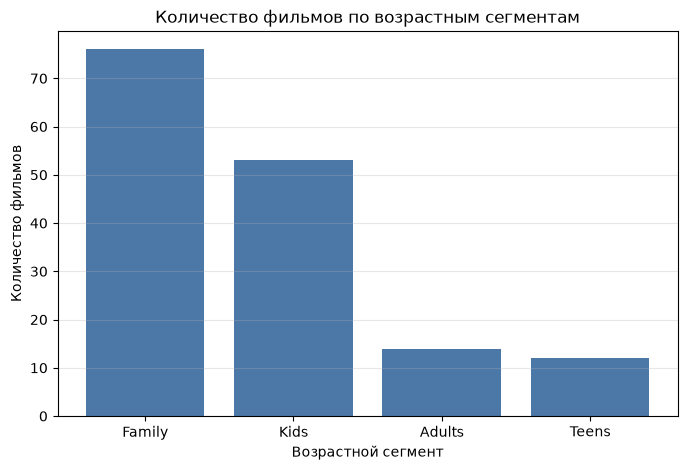

In [10]:
segment_counts = df_movies['audience_segment_cat'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values, color='#4C78A8')
plt.title('Количество фильмов по возрастным сегментам')
plt.xlabel('Возрастной сегмент')
plt.ylabel('Количество фильмов')
plt.grid(axis='y', alpha=0.3)
plt.show()

По количеству фильмов заметно, что в выборке сильнее всего представлены Family и Kids. Это отличает фильмы от сериалов, где больше контента для подростков и взрослых. Похоже, фильмовая часть библиотеки Netflix в этом датасете больше ориентирована на семейный просмотр и детскую аудиторию.

## Агрегация по жанровым группам

Теперь посмотрю, какие жанровые группы встречаются чаще и какие у них оценки.

In [11]:
genre_stats = df_movies.groupby('genre_group').agg(
    films_count=('title', 'count'),
    user_rating_mean=('user rating score', 'mean'),
    user_rating_median=('user rating score', 'median'),
    imdb_rating_mean=('imdbRating', 'mean')
).reset_index()

genre_stats['user_rating_mean'] = genre_stats['user_rating_mean'].round(2)
genre_stats['user_rating_median'] = genre_stats['user_rating_median'].round(2)
genre_stats['imdb_rating_mean'] = genre_stats['imdb_rating_mean'].round(2)

genre_stats.sort_values('films_count', ascending=False)

,genre_group,films_count,user_rating_mean,user_rating_median,imdb_rating_mean
0,Анимация и семейные,73,83.13,91.0,6.36
3,Комедия и легкое кино,26,74.94,77.0,5.74
1,Без жанра,21,75.00,74.5,NaN
4,Приключения и фантастика,17,84.36,82.0,6.04
2,Драма и биографии,9,77.80,78.0,6.68
5,Экшен и напряженные жанры,9,81.60,91.0,5.86


### Количество фильмов по жанровым группам

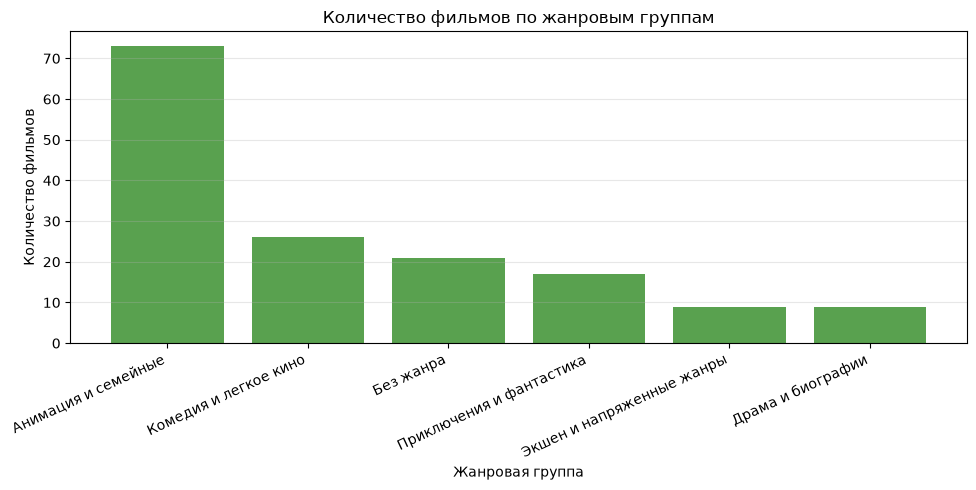

In [12]:
genre_counts = df_movies['genre_group'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(genre_counts.index, genre_counts.values, color='#59A14F')
plt.title('Количество фильмов по жанровым группам')
plt.xlabel('Жанровая группа')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

В жанрах тоже видно смещение в сторону более легкого контента: много анимации, семейных фильмов, комедий и приключений. Это хорошо совпадает с распределением по возрастным сегментам, где лидируют Family и Kids.

## Оценки по возрастным сегментам

Количество фильмов показывает структуру каталога, но отдельно нужно посмотреть оценки. Для этого использую boxplot, потому что на нем виден разброс оценок внутри каждой группы.

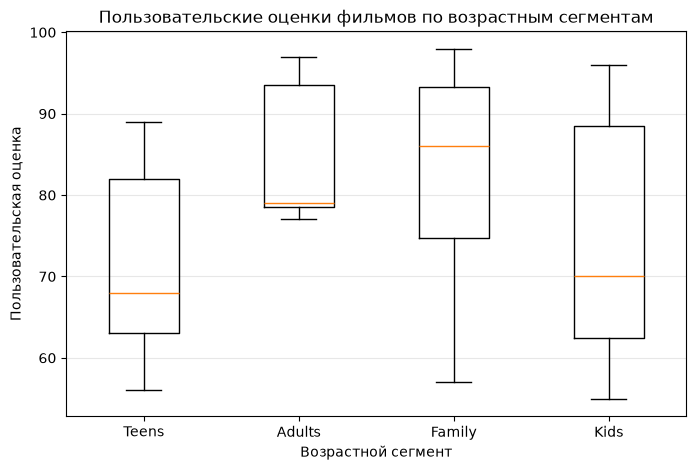

In [16]:
ratings_for_boxplot = []
labels = []

for segment in df_movies['audience_segment_cat'].dropna().unique():
    segment_ratings = df_movies.loc[df_movies['audience_segment_cat'] == segment, 'user rating score'].dropna()
    if len(segment_ratings) > 0:
        ratings_for_boxplot.append(segment_ratings)
        labels.append(segment)

plt.figure(figsize=(8, 5))
plt.boxplot(ratings_for_boxplot, tick_labels=labels)
plt.title('Пользовательские оценки фильмов по возрастным сегментам')
plt.xlabel('Возрастной сегмент')
plt.ylabel('Пользовательская оценка')
plt.grid(axis='y', alpha=0.3)
plt.show()

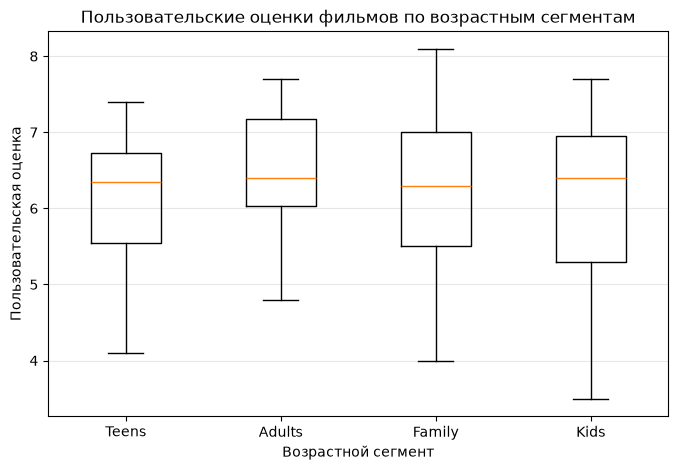

In [17]:
ratings_for_boxplot = []
labels = []

for segment in df_movies['audience_segment_cat'].dropna().unique():
    segment_ratings = df_movies.loc[df_movies['audience_segment_cat'] == segment, 'imdbRating'].dropna()
    if len(segment_ratings) > 0:
        ratings_for_boxplot.append(segment_ratings)
        labels.append(segment)

plt.figure(figsize=(8, 5))
plt.boxplot(ratings_for_boxplot, tick_labels=labels)
plt.title('Пользовательские оценки фильмов по возрастным сегментам')
plt.xlabel('Возрастной сегмент')
plt.ylabel('Пользовательская оценка')
plt.grid(axis='y', alpha=0.3)
plt.show()

По пользовательским оценкам видно, что важен не только размер группы, но и разброс. У некоторых сегментов фильмов много, но оценки распределены шире. Это значит, что внутри одной возрастной категории могут быть как очень удачные, так и слабые фильмы.

## Динамика по годам

В конце посмотрю, как менялось количество фильмов по годам и что происходило со средними оценками. Тут важно помнить, что в некоторых годах фильмов мало, поэтому средняя оценка может сильно прыгать.

In [18]:
yearly_stats = df_movies.groupby('release year').agg(
    films_count=('title', 'count'),
    user_rating_mean=('user rating score', 'mean'),
    imdb_rating_mean=('imdbRating', 'mean')
).reset_index()

yearly_stats['user_rating_mean'] = yearly_stats['user_rating_mean'].round(2)
yearly_stats['imdb_rating_mean'] = yearly_stats['imdb_rating_mean'].round(2)

yearly_stats.tail(10)

,release year,films_count,user_rating_mean,imdb_rating_mean
23,2007,3,94.00,6.00
24,2008,4,79.00,5.75
25,2009,2,75.50,6.25
26,2010,1,NaN,6.00
27,2011,5,NaN,5.98
28,2012,7,68.33,6.37
29,2013,6,62.00,5.63
30,2014,10,63.50,5.84
31,2015,12,85.00,6.06
32,2016,23,89.59,6.31


### Количество фильмов и оценки по годам

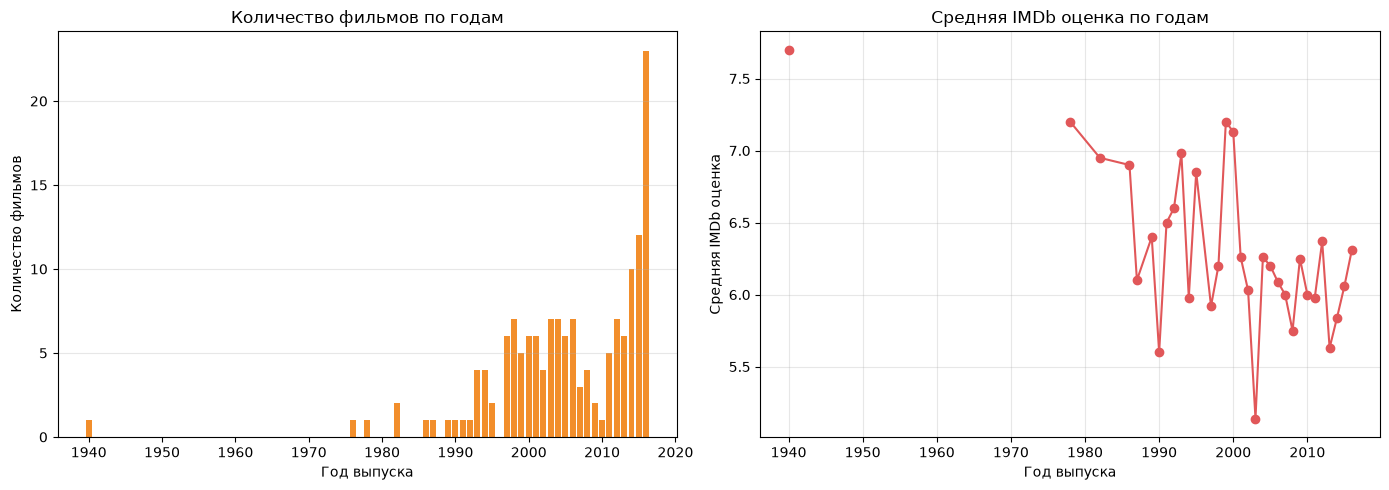

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly_stats['release year'], yearly_stats['films_count'], color='#F28E2B')
axes[0].set_title('Количество фильмов по годам')
axes[0].set_xlabel('Год выпуска')
axes[0].set_ylabel('Количество фильмов')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(yearly_stats['release year'], yearly_stats['imdb_rating_mean'], marker='o', color='#E15759')
axes[1].set_title('Средняя IMDb оценка по годам')
axes[1].set_xlabel('Год выпуска')
axes[1].set_ylabel('Средняя IMDb оценка')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

По годам заметно, что основная часть фильмов в выборке относится к 2000-м и 2010-м годам. Особенно выделяется 2016 год: в нем фильмов больше всего. Это похоже на общую особенность датасета Netflix, где много контента собрано вокруг периода активного расширения платформы.

Средняя IMDb оценка по годам меняется неравномерно. Но здесь нельзя делать слишком жесткий вывод, потому что в ранних годах фильмов мало, и один-два фильма могут сильно влиять на среднее.

## Итоговые выводы

В анализе фильмов видно несколько закономерностей.

Во-первых, фильмы в этом датасете в основном ориентированы на семейную и детскую аудиторию. Это отличается от анализа ТВ-шоу, где сильнее выделялись подростковые и взрослые сегменты.

Во-вторых, по жанрам чаще встречаются анимация, семейное кино, комедии и приключения. То есть фильмовая часть Netflix в этой выборке больше похожа на каталог для массового и семейного просмотра.

В-третьих, оценки нельзя анализировать по всем фильмам сразу без оговорок, потому что часть значений отсутствует. Поэтому в расчетах использовались только реальные оценки, без заполнения пропусков.

В-четвертых, по годам заметен рост количества фильмов ближе к 2010-м, а максимум приходится на 2016 год. При этом средние оценки по годам лучше воспринимать осторожно, потому что в некоторые годы фильмов слишком мало для надежного сравнения.